In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import json

from CMR_IA.utils import wmse
from CMR_IA.fitting import _simu8_g1_stats

cmr.analysis.setup_notebook()

SAVEFIG = True
RUNCMR = True
SAVERES = True
if SAVERES and not RUNCMR:
    print("Warning: SAVERES is ignored when RUNCMR is False; existing results are loaded instead.")

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu8_study.parquet")
df_test = pd.read_parquet("data/simu8_test.parquet")

In [3]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session
0,12,24,Face12,Joe,0,0,0
1,2,29,Face2,Mark,1,0,0
2,6,27,Face6,Dan,2,0,0
3,13,18,Face13,John,3,0,0
4,11,31,Face11,George,4,0,0
...,...,...,...,...,...,...,...
79995,8,30,Face8,Mike,3,0,9999
79996,9,24,Face9,Joe,4,0,9999
79997,7,28,Face7,Paul,5,0,9999
79998,16,23,Face16,Charles,6,0,9999


In [4]:
# Inspect test data
df_test

,test_itemno,test_item,correct_ans,study_pos,test,list,session
0,1,Face1,30,6,1,0,0
1,2,Face2,29,1,1,0,0
2,6,Face6,27,2,1,0,0
3,14,Face14,22,7,1,0,0
4,13,Face13,18,3,1,0,0
...,...,...,...,...,...,...,...
79995,1,Face1,20,1,1,0,9999
79996,15,Face15,25,0,1,0,9999
79997,8,Face8,30,3,1,0,9999
79998,16,Face16,23,6,1,0,9999


In [5]:
# Load semantic matrix
sem_mat = np.load("data/simu8_smat.npy")

## Run CMR-IA

In [6]:
# Define parameters and load PSO results
params = cmr.load_params("8", fixed_params={"nitems_in_accumulator": 16, "ban_recall": np.arange(1, 17)})
params

{'beta_enc': 0.996362,
 'beta_rec': 0.243174,
 'beta_cue': 0.908035,
 'beta_rec_post': 0.0,
 'beta_distract': 0.64988,
 'beta_enc_inpair': None,
 's_fc': 1.014524,
 's_cf': 0.0,
 'phi_s': 3.459562,
 'phi_d': 3.397916,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 1.153296,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.0,
 'c_thresh_assoc': 1.0,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.26505,
 'eta': 0.037573,
 'omega': 9.022988,
 'alpha': 0.692554,
 'lamb': 0.065877,
 'c_thresh_rec': 0.403354,
 'ban_recall': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 16,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'gamma_fc': 0.487281,
 'gamma_cf': 0.827241}

In [7]:
# Run model or load saved results
if RUNCMR:
    df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    if SAVERES:
        df_simu.to_parquet("data/simu8_result.parquet")
else:
    df_simu = pd.read_parquet("data/simu8_result.parquet")
df_simu

  0%|          | 21/10000 [00:00<00:49, 203.15it/s]

100%|██████████| 10000/10000 [00:49<00:00, 203.65it/s]


CMR Time: 49.40687680244446


,session,list,test_itemno,s_resp,s_rt,csim,thresh,test_item,correct_ans,study_pos,test
0,0,0,1,24,530,0.314195,0.197872,Face1,30,6,1
1,0,0,2,29,1940,0.635847,0.149183,Face2,29,1,1
2,0,0,6,27,1900,0.633213,0.222612,Face6,27,2,1
3,0,0,14,22,2280,0.639526,0.245059,Face14,22,7,1
4,0,0,13,18,2480,0.638855,0.253886,Face13,18,3,1
...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,18,1850,0.411030,0.225108,Face1,20,1,1
79996,9999,0,15,25,1500,0.636482,0.184511,Face15,25,0,1
79997,9999,0,8,-1,-1,-1.000000,-1.000000,Face8,30,3,1
79998,9999,0,16,32,3710,0.389030,0.233937,Face16,23,6,1


In [8]:
# Check omission count
df_simu.query("s_resp == -2").shape

(643, 11)

In [9]:
# Check no-response count
df_simu.query("s_resp == -1").shape

(5573, 11)

## Analysis

Not so suitable for a session-wise analysis. I just pool them together.

In [10]:
# Get correction flag
df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,thresh,test_item,correct_ans,study_pos,test,correct
0,0,0,1,24,530,0.314195,0.197872,Face1,30,6,1,False
1,0,0,2,29,1940,0.635847,0.149183,Face2,29,1,1,True
2,0,0,6,27,1900,0.633213,0.222612,Face6,27,2,1,True
3,0,0,14,22,2280,0.639526,0.245059,Face14,22,7,1,True
4,0,0,13,18,2480,0.638855,0.253886,Face13,18,3,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,18,1850,0.411030,0.225108,Face1,20,1,1,False
79996,9999,0,15,25,1500,0.636482,0.184511,Face15,25,0,1,True
79997,9999,0,8,-1,-1,-1.000000,-1.000000,Face8,30,3,1,False
79998,9999,0,16,32,3710,0.389030,0.233937,Face16,23,6,1,False


In [11]:
# Check correct rate
correct_rate = sum(df_simu.correct) / len(df_simu.correct)
correct_rate

0.6677

### Neighborhood Effect

In [12]:
# Load face distance matrix and compute neighbour counts
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0


def get_distance(df_tmp):
    faces = np.unique(df_tmp.test_itemno)
    face_dist = {}
    for face in faces:
        this_dist = []
        for other_face in faces:
            if face != other_face:
                this_dist.append(face_distance[face - 1, other_face - 1])
        this_dist = np.array(this_dist)
        face_dist[face] = this_dist
    y = df_tmp.apply(lambda x: face_dist[x["test_itemno"]], axis=1)
    return y


# Get number of neighbours by distance
df_simu["distance"] = df_simu.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]
df_simu["neighbour"] = df_simu.apply(lambda x: sum(x["distance"] < thresh), axis=1)
distance_lsts = df_simu["distance"].to_list()
df_simu.drop(columns=["distance"], inplace=True)
df_simu["neighbour_group"] = df_simu.apply(lambda x: 6 if x["neighbour"] == 7 else x["neighbour"], axis=1)
df_simu

/tmp/ipykernel_19870/1445371699.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu["distance"] = df_simu.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]


,session,list,test_itemno,s_resp,s_rt,csim,thresh,test_item,correct_ans,study_pos,test,correct,neighbour,neighbour_group
0,0,0,1,24,530,0.314195,0.197872,Face1,30,6,1,False,4,4
1,0,0,2,29,1940,0.635847,0.149183,Face2,29,1,1,True,4,4
2,0,0,6,27,1900,0.633213,0.222612,Face6,27,2,1,True,3,3
3,0,0,14,22,2280,0.639526,0.245059,Face14,22,7,1,True,3,3
4,0,0,13,18,2480,0.638855,0.253886,Face13,18,3,1,True,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,18,1850,0.411030,0.225108,Face1,20,1,1,False,4,4
79996,9999,0,15,25,1500,0.636482,0.184511,Face15,25,0,1,True,5,5
79997,9999,0,8,-1,-1,-1.000000,-1.000000,Face8,30,3,1,False,3,3
79998,9999,0,16,32,3710,0.389030,0.233937,Face16,23,6,1,False,4,4


In [13]:
# Count items per neighbour group
df_simu.groupby("neighbour_group").test_itemno.count()

neighbour_group
0      250
1     2653
2     9854
3    20368
4    24849
5    16605
6     5421
Name: test_itemno, dtype: int64

In [14]:
# Get correct rate by neighbour group
df_neighbour_group = df_simu.query("neighbour_group > 0").groupby("neighbour_group").correct.mean().reset_index()
df_neighbour_group

,neighbour_group,correct
0,1,0.770825
1,2,0.721331
2,3,0.685978
3,4,0.657612
4,5,0.633243
5,6,0.594171


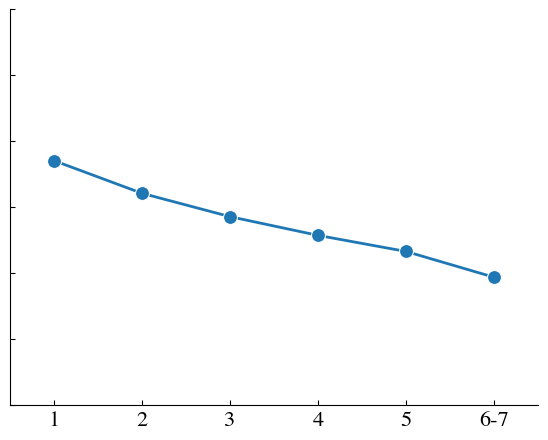

In [15]:
# Plot neighbourhood effect
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(
    data=df_neighbour_group,
    x="neighbour_group",
    y="correct",
    linewidth=2,
    marker="o",
    markersize=10,
    label=str(thresh),
)
plt.ylim([0.4, 1])
plt.xlim([0.5, 6.5])
plt.xticks(ticks=np.arange(1, 7), labels=["1", "2", "3", "4", "5", "6-7"])
plt.xlabel("Number of Neighbours")
plt.ylabel("P(Correct)")
plt.legend().set_visible(False)

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_correct-neighbor.pdf")
plt.show()

### ILI

In [16]:
# Detect ILI responses
def get_ILI(df_tmp):
    resp_names = df_tmp["s_resp"].values
    study_names = df_tmp["correct_ans"].values  # all correct answers are all studied names
    is_studied = np.isin(resp_names, study_names)
    is_incorrect = df_tmp["correct"] == False
    is_ILI = is_studied & is_incorrect
    return is_ILI


df_simu["ILI"] = df_simu.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()
df_ILI = df_simu.query("ILI == True").copy()
df_ILI

/tmp/ipykernel_19870/1259149172.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu["ILI"] = df_simu.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()


,session,list,test_itemno,s_resp,s_rt,csim,thresh,test_item,correct_ans,study_pos,test,correct,neighbour,neighbour_group,ILI
0,0,0,1,24,530,0.314195,0.197872,Face1,30,6,1,False,4,4,True
8,1,0,12,21,520,0.322428,0.195968,Face12,25,1,1,False,4,4,True
10,1,0,3,31,2240,0.363738,0.221585,Face3,21,0,1,False,4,4,True
14,1,0,5,21,1290,0.378431,0.252638,Face5,31,5,1,False,3,3,True
20,2,0,9,29,1950,0.388320,0.253059,Face9,21,2,1,False,3,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79990,9998,0,3,20,4040,0.273162,0.233683,Face3,18,2,1,False,4,4,True
79992,9999,0,3,25,670,0.278739,0.188718,Face3,18,2,1,False,3,3,True
79993,9999,0,6,30,1590,0.411465,0.136506,Face6,32,7,1,False,3,3,True
79995,9999,0,1,18,1850,0.411030,0.225108,Face1,20,1,1,False,4,4,True


In [17]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study.session.unique():
    sess_name_face[sess] = df_study.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

In [18]:
# Get distance between ILI and correct faces
df_ILI["resp_face"] = df_ILI.apply(lambda x: sess_name_face[x["session"]][x["s_resp"]], axis=1)
df_ILI["resp_corr_distance"] = df_ILI.apply(lambda x: face_distance[x["test_itemno"] - 1, x["resp_face"] - 1], axis=1)
df_ILI["distance_bin"] = df_ILI.apply(lambda x: str(0.5 * (x["resp_corr_distance"] // 0.5 + 1)) if x["resp_corr_distance"] < 3.5 else ">3.5", axis=1)
df_ILI["distance_bin"] = pd.Categorical(df_ILI["distance_bin"], categories=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"], ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,thresh,test_item,correct_ans,study_pos,test,correct,neighbour,neighbour_group,ILI,resp_face,resp_corr_distance,distance_bin
0,0,0,1,24,530,0.314195,0.197872,Face1,30,6,1,False,4,4,True,12,2.5733,3.0
8,1,0,12,21,520,0.322428,0.195968,Face12,25,1,1,False,4,4,True,3,2.3944,2.5
10,1,0,3,31,2240,0.363738,0.221585,Face3,21,0,1,False,4,4,True,5,1.8175,2.0
14,1,0,5,21,1290,0.378431,0.252638,Face5,31,5,1,False,3,3,True,3,1.8175,2.0
20,2,0,9,29,1950,0.388320,0.253059,Face9,21,2,1,False,3,3,True,15,2.0873,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79990,9998,0,3,20,4040,0.273162,0.233683,Face3,18,2,1,False,4,4,True,9,3.0111,3.5
79992,9999,0,3,25,670,0.278739,0.188718,Face3,18,2,1,False,3,3,True,15,2.9509,3.0
79993,9999,0,6,30,1590,0.411465,0.136506,Face6,32,7,1,False,3,3,True,8,1.1045,1.5
79995,9999,0,1,18,1850,0.411030,0.225108,Face1,20,1,1,False,4,4,True,3,1.0900,1.5


In [19]:
# Count possible ILI from all distances
distance_cnt = {}
for lst in distance_lsts:
    for d in lst:
        d_group = str(0.5 * (d // 0.5 + 1)) if d < 3.5 else ">3.5"
        if d_group in distance_cnt:
            distance_cnt[d_group] += 1
        else:
            distance_cnt[d_group] = 1

In [20]:
# Get ILI probability by distance bin
df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()
df_ILI_distance["ILI_poss"] = df_ILI_distance.apply(lambda x: distance_cnt[x["distance_bin"]], axis=1)
df_ILI_distance["ILI_prob"] = df_ILI_distance["ILI_cnt"] / df_ILI_distance["ILI_poss"]
df_ILI_distance

/tmp/ipykernel_19870/2353333076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()


,distance_bin,ILI_cnt,ILI_poss,ILI_prob
0,1.0,1305,9136,0.142842
1,1.5,3482,28218,0.123396
2,2.0,2077,27948,0.074317
3,2.5,4773,102562,0.046538
4,3.0,4059,131028,0.030978
5,3.5,3299,163462,0.020182
6,>3.5,1373,97646,0.014061


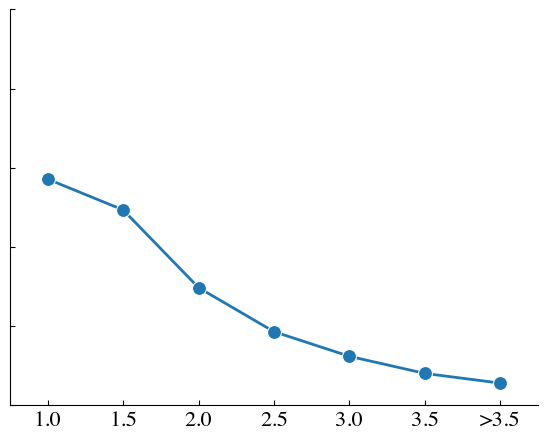

In [21]:
# Plot ILI by distance bin
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_ILI_distance, x="distance_bin", y="ILI_prob", linewidth=2, marker="o", markersize=10)
plt.ylim([0, 0.25])
plt.xlim([-0.5, 6.5])
plt.xlabel("Distance Bins")
plt.ylabel("ILI Conditional Response Probability")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_ILI-distance.pdf")
plt.show()

## Err Check

In [22]:
# Load ground truth
with open("data/simu8_gt.json") as f:
    gt = json.load(f)
neighbor_mean_gt = np.array(gt["exp1_neighbor_mean"])
neighbor_se_gt = np.array(gt["exp1_neighbor_se"])
ILI_mean_gt = np.array(gt["exp1_ILI_mean"])
ILI_se_gt = np.array(gt["exp1_ILI_se"])

In [23]:
# Compute weighted mean squared error
neighbor_mean = df_neighbour_group["correct"].to_numpy()
ILI_mean = df_ILI_distance["ILI_prob"].to_numpy()
wls_neighbor = wmse(neighbor_mean_gt, neighbor_mean, neighbor_se_gt) / len(neighbor_mean_gt)
wls_ILI = wmse(ILI_mean_gt, ILI_mean, ILI_se_gt) / len(ILI_mean_gt)
wls_neighbor, wls_ILI

(0.44698115283441714, 2.231571388936763)

In [24]:
# Compute total error
err = wls_neighbor + wls_ILI
err

2.67855254177118

In [26]:
# Verify fitting helper
_, _, _, v_wls_neighbor, v_wls_ILI = _simu8_g1_stats(df_simu, df_study, face_distance, thresh, gt)
v_wls_neighbor, v_wls_ILI

(0.44698115283441714, 2.231571388936763)